# K-Nearest Neighbors (KNN) - Student Placement Prediction

## 1: Data Cleaning & Splitting


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# Load Dataset
candidates = [
    'student_placement_prediction_dataset_2026.csv',
    '../student_placement_prediction_dataset_2026.csv',
    'ml_source/student_placement_prediction_dataset_2026.csv',
]
dataset_path = next((p for p in candidates if os.path.exists(p)), 'student_placement_prediction_dataset_2026.csv')
df = pd.read_csv(dataset_path)
df.head()


,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,19,Male,6.32,Mechanical,Tier 2,2,4,5,80.915699,...,95.701310,89.815748,4,73.651880,65.230454,No,4.8,7.5,Not Placed,0.0
1,2,19,Male,7.88,CSE,Tier 1,2,5,8,70.836174,...,72.657083,91.711234,4,74.829306,80.561675,Yes,7.9,3.3,Not Placed,0.0
2,3,21,Female,7.96,IT,Tier 2,3,4,3,79.106647,...,64.687791,59.176635,4,40.080468,57.125656,No,5.6,1.6,Not Placed,0.0
3,4,21,Male,6.72,CSE,Tier 1,1,5,2,75.362650,...,74.041055,87.675137,4,82.601874,59.523842,No,6.5,2.7,Not Placed,0.0
4,5,24,Male,7.75,Mechanical,Tier 2,1,6,3,63.974469,...,72.968318,100.000000,4,52.559966,51.318936,No,7.4,2.3,Not Placed,0.0


In [3]:
df.columns


Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='str')

In [4]:
df.describe()


,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,20.922667,7.540153,1.486000,3.026667,2.055333,69.810581,64.665648,68.192092,65.524865,...,3.976000,522.637333,69.943129,84.651677,0.522667,60.290434,54.827069,6.983667,3.536933,5.098847
std,433.157015,2.011480,0.951340,1.197258,1.756895,1.404844,15.064602,14.708885,13.899221,15.499127,...,1.988482,270.298018,11.783603,9.352264,0.813589,19.569152,20.075901,1.489481,1.482185,5.029873
min,1.000000,18.000000,4.500000,0.000000,0.000000,0.000000,22.514600,20.000000,20.976991,20.000000,...,0.000000,50.000000,33.296869,51.418364,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,375.750000,19.000000,6.930000,1.000000,2.000000,1.000000,59.476284,53.954934,58.654912,54.715305,...,3.000000,306.750000,62.384946,78.219539,0.000000,46.480280,41.983352,6.000000,2.500000,0.000000
50%,750.500000,21.000000,7.535000,1.000000,3.000000,2.000000,70.010432,64.723057,68.112268,65.352926,...,4.000000,515.500000,70.127980,84.981144,0.000000,60.164068,54.661797,7.000000,3.600000,5.595000
75%,1125.250000,23.000000,8.162500,2.000000,4.000000,3.000000,80.251606,74.271954,77.836866,76.432398,...,5.000000,751.250000,78.210660,91.240373,1.000000,74.108379,68.305692,8.000000,4.500000,9.582500
max,1500.000000,24.000000,10.000000,7.000000,11.000000,8.000000,100.000000,100.000000,100.000000,100.000000,...,13.000000,997.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,8.500000,17.540000


In [5]:
df.shape


(1500, 26)

In [6]:
df.isnull().sum()


student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [7]:
# Convert target to 0 and 1
if df['placement_status'].dtype == object or df['placement_status'].dtype == 'string':
    df['placement_status'] = df['placement_status'].map({'Not Placed': 0, 'Placed': 1})

# Feature Engineering (Domain Indicators)
df['academic_clearance_score'] = df['cgpa'] * np.exp(-0.30 * df['backlogs'])
df['has_zero_backlogs'] = (df['backlogs'] == 0).astype(int)
df['technical_mastery'] = 0.40 * df['coding_skill_score'] + 0.25 * df['aptitude_score'] + 0.20 * df['logical_reasoning_score'] + 0.15 * df['mock_interview_score']
df['experience_index'] = df['internships_count'] * 3.5 + df['projects_count'] * 1.5 + df['hackathons_participated'] * 1.5 + df['certifications_count'] * 0.8
df['placement_readiness_score'] = 0.35 * (df['academic_clearance_score'] * 10) + 0.35 * df['technical_mastery'] + 0.20 * np.clip(df['experience_index'] * 5, 0, 100) + 0.10 * df['attendance_percentage']

# Features and Target
X = df.drop(columns=['student_id', 'placement_status', 'salary_package_lpa'])
X = pd.get_dummies(X, drop_first=True)
y = df['placement_status']

print('Features:')
print(X.columns)

print('\nTarget:')
print(y.name)

print('\nTarget Class Distribution:\n')
print(y.value_counts())


Features:
Index(['age', 'cgpa', 'internships_count', 'projects_count',
       'certifications_count', 'coding_skill_score', 'aptitude_score',
       'communication_skill_score', 'logical_reasoning_score',
       'hackathons_participated', 'github_repos', 'linkedin_connections',
       'mock_interview_score', 'attendance_percentage', 'backlogs',
       'extracurricular_score', 'leadership_score', 'sleep_hours',
       'study_hours_per_day', 'academic_clearance_score', 'has_zero_backlogs',
       'technical_mastery', 'experience_index', 'placement_readiness_score',
       'gender_Male', 'branch_Civil', 'branch_ECE', 'branch_EEE', 'branch_IT',
       'branch_Mechanical', 'college_tier_Tier 2', 'college_tier_Tier 3',
       'volunteer_experience_Yes'],
      dtype='str')

Target:
placement_status

Target Class Distribution:

placement_status
1    819
0    681
Name: count, dtype: int64


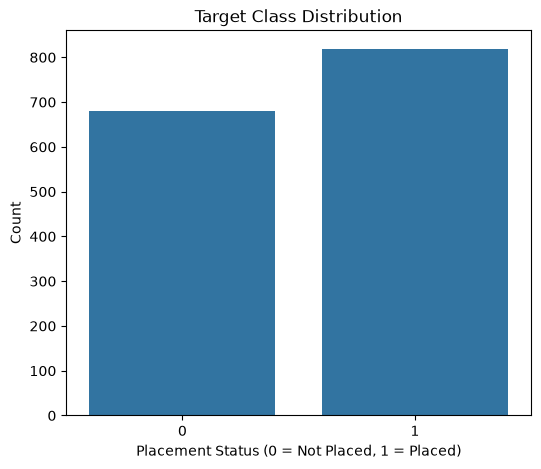

In [8]:
plt.figure(figsize=(6, 5))
sns.countplot(x=y)
plt.title('Target Class Distribution')
plt.xlabel('Placement Status (0 = Not Placed, 1 = Placed)')
plt.ylabel('Count')
plt.show()


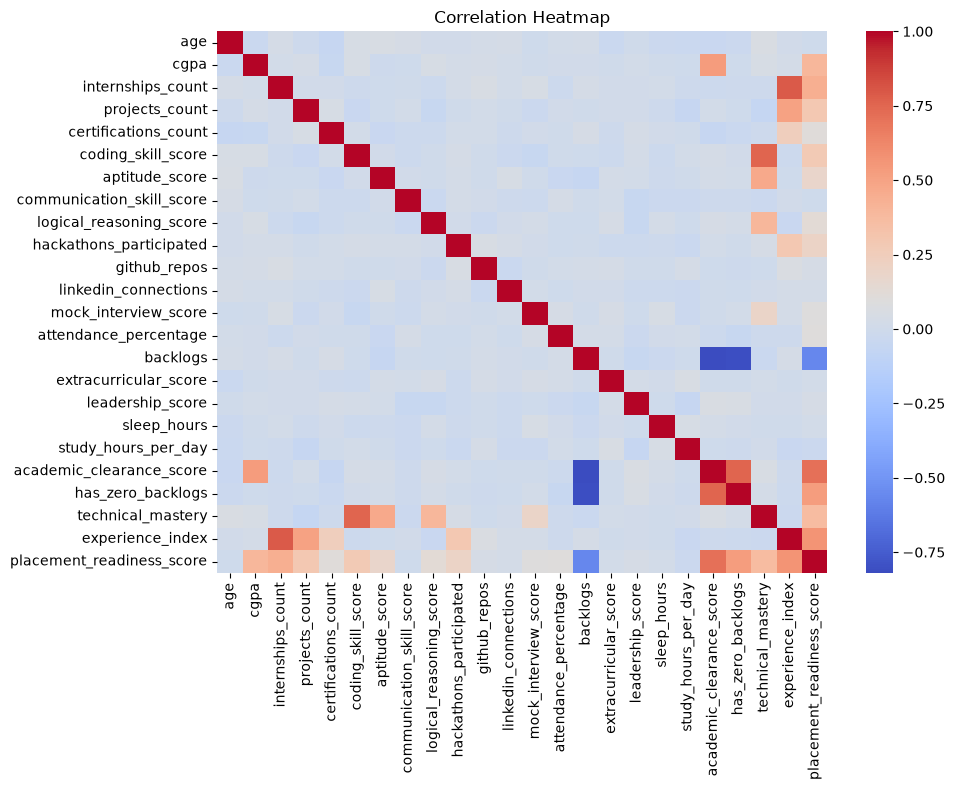

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.select_dtypes(include=[np.number]).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [10]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled Data:')
print(X_scaled)


Scaled Data:
[[-0.5        -0.98580122  1.         ...  1.          0.
   0.        ]
 [-0.5         0.27991886  1.         ...  0.          0.
   1.        ]
 [ 0.          0.34482759  2.         ...  1.          0.
   0.        ]
 ...
 [ 0.75        0.9127789  -1.         ...  0.          1.
   1.        ]
 [-0.5        -0.88032454  1.         ...  1.          0.
   1.        ]
 [-0.75        2.          1.         ...  1.          0.
   0.        ]]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)
print('Training labels:', y_train.shape)
print('Testing labels:', y_test.shape)


Training data shape: (1200, 33)
Testing data shape: (300, 33)
Training labels: (1200,)
Testing labels: (300,)


## 2: K-Nearest Neighbors (KNN) Model


In [12]:
model = KNeighborsClassifier(n_neighbors=13, weights='distance', p=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.head(15)


,Actual,Predicted
0,0,0
1,1,1
2,1,1
3,0,0
4,0,0
5,0,0
6,1,1
7,1,1
8,1,1
9,0,0


Accuracy: 91.67 %

Classification Report:

              precision    recall  f1-score   support

  Not Placed       0.96      0.85      0.90       136
      Placed       0.89      0.97      0.93       164

    accuracy                           0.92       300
   macro avg       0.92      0.91      0.91       300
weighted avg       0.92      0.92      0.92       300



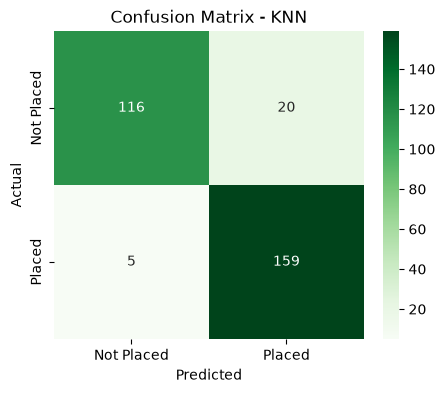

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', round(accuracy * 100, 2), '%')

print('\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['Not Placed', 'Placed']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [14]:
# Predict on a sample student from test set
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0][1]

print('Predicted Class:', prediction)
print(f'Placement Probability: {probability * 100:.2f}%')
if prediction == 1:
    print('Placement Status: Placed')
else:
    print('Placement Status: Not Placed')


Predicted Class: 0
Placement Probability: 0.00%
Placement Status: Not Placed


In [15]:
# Save Model and Scaler
joblib.dump(model, 'knn.pkl')
joblib.dump(scaler, 'scaler_knn.pkl')
print('Model saved as knn.pkl and scaler as scaler_knn.pkl')


Model saved as knn.pkl and scaler as scaler_knn.pkl
